# EDA on Raw Messages

Coco Yu  
October 7, 2024

## Code Status

## Notes

## Setup

Chunk Defaults

In [ ]:
knitr::opts_chunk$set(attr.output='style="max-height: 500px;"')


Conflicts

In [ ]:
options(conflicts.policy = "depends.ok")


In [ ]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at /Users/yujiachen/Desktop/github/study_messages

Source Functions

In [ ]:
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "c045eee2655a18dc85e715b78182f176327358a7"

Absolute Paths

In [ ]:
path_shared <- format_path(str_c("studydata/risk/data_processed/shared"))
path_messages <- format_path(str_c("studydata/risk/data_processed/messages"))


Read in Data

In [ ]:
# raw messages that have been cleaned
raw_data <- read_csv(
    here(path_messages, "cleaned_messages.csv"),
    col_types = cols(
        subid = "d", address = "c", contact_type = "f", date = "T", type = "f", 
        body = "c", msg_type = "f", phone_type = "f"
    )
)

# individual messages mapped on to prediction windows
pred_3day <- read_csv(
    here(path_messages, "predictors/pred_3day.csv"),
    col_types = cols(
        subid = "d", day_start = "T", day_end = "T", lapse = "f", pred_onset = "T",
        address = "c", contact_type = "f", date = "T", type = "f", body = "c",
        msg_type = "f", phone_type = "f"
    )
)
pred_1week <- read_csv(
    here(path_messages, "predictors/pred_1week.csv"),
    col_types = cols(
        subid = "d", day_start = "T", day_end = "T", lapse = "f", pred_onset = "T",
        address = "c", contact_type = "f", date = "T", type = "f", body = "c",
        msg_type = "f", phone_type = "f"
    )
)

# concatenated text messages mapped on to prediction windows
cat_3day <- read_csv(
    here(path_messages, "predictors/doc_3day.csv"),
    col_types = cols(
        subid = "d", day_start = "T", body = "c", lapse = "f"
    )
)

cat_1week <- read_csv(
    here(path_messages, "predictors/doc_1week.csv"),
    col_types = cols(
        subid = "d", day_start = "T", body = "c", lapse = "f"
    )
)

# labels
labels <- read_csv(here(path_messages, "lapses.csv"), col_types = cols()) |> 
  mutate(day_start = as_datetime(day_start, tz = "America/Chicago"),
         day_end = as_datetime(day_end, tz = "America/Chicago"))


## EDA on lapse labels

> **Summary Table**

> Conclusion 1: The total number of lapse labels in the dataset is 11562.

> Conclusion 2: On average, each participant has 83.8 labels (sd = 11.4, median = 88, range = 30 - 90).

In [ ]:
(nrow(labels))


[1] 11562

# A tibble: 1 × 5
   mean    sd median   min   max
  <dbl> <dbl>  <dbl> <int> <int>
1  83.8  11.4     88    30    90

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

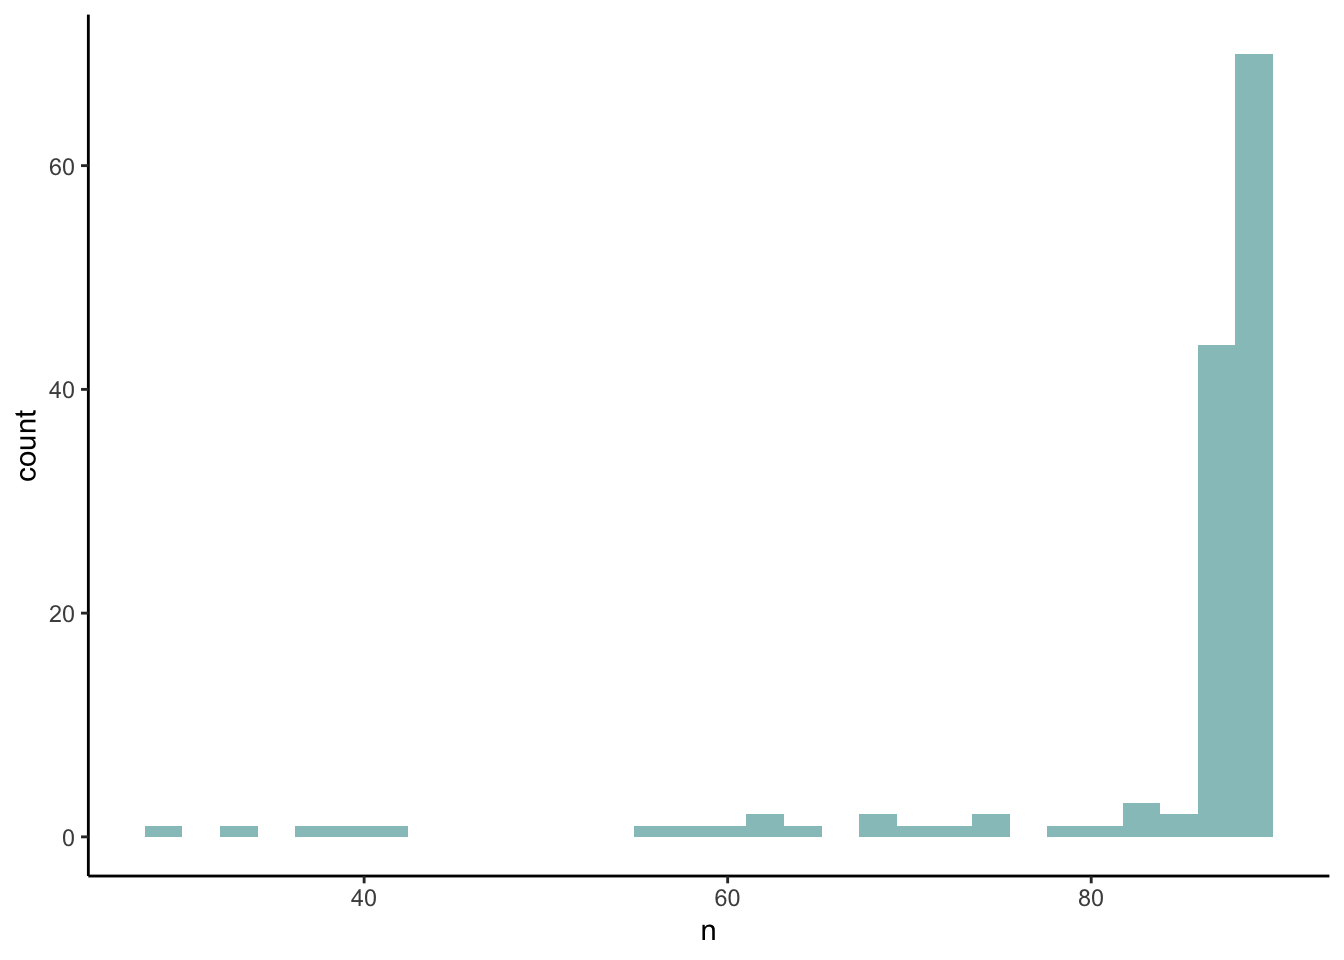

In [ ]:
labels |> 
  group_by(subid) |> 
  summarize(n = n()) |> 
  ggplot(aes(x = n)) + 
  geom_histogram(fill = "#97C4C5")


## EDA on raw messages

In total, the study has 138 subjects.

In [ ]:
raw_data |> 
  pull(subid) |> 
  unique() |> 
  length()


[1] 138

### Message counts per participant

> **Summary Table**

> Conclusion 1: The total number of messages in the dataset is 313492.

> Conclusion 2: On average, each subject has 2271.68 messages (sd = 2536.6, range = 100 - 15884).

In [ ]:
(nrow(raw_data))


[1] 313492

**Histogram on \# of messages per participant**

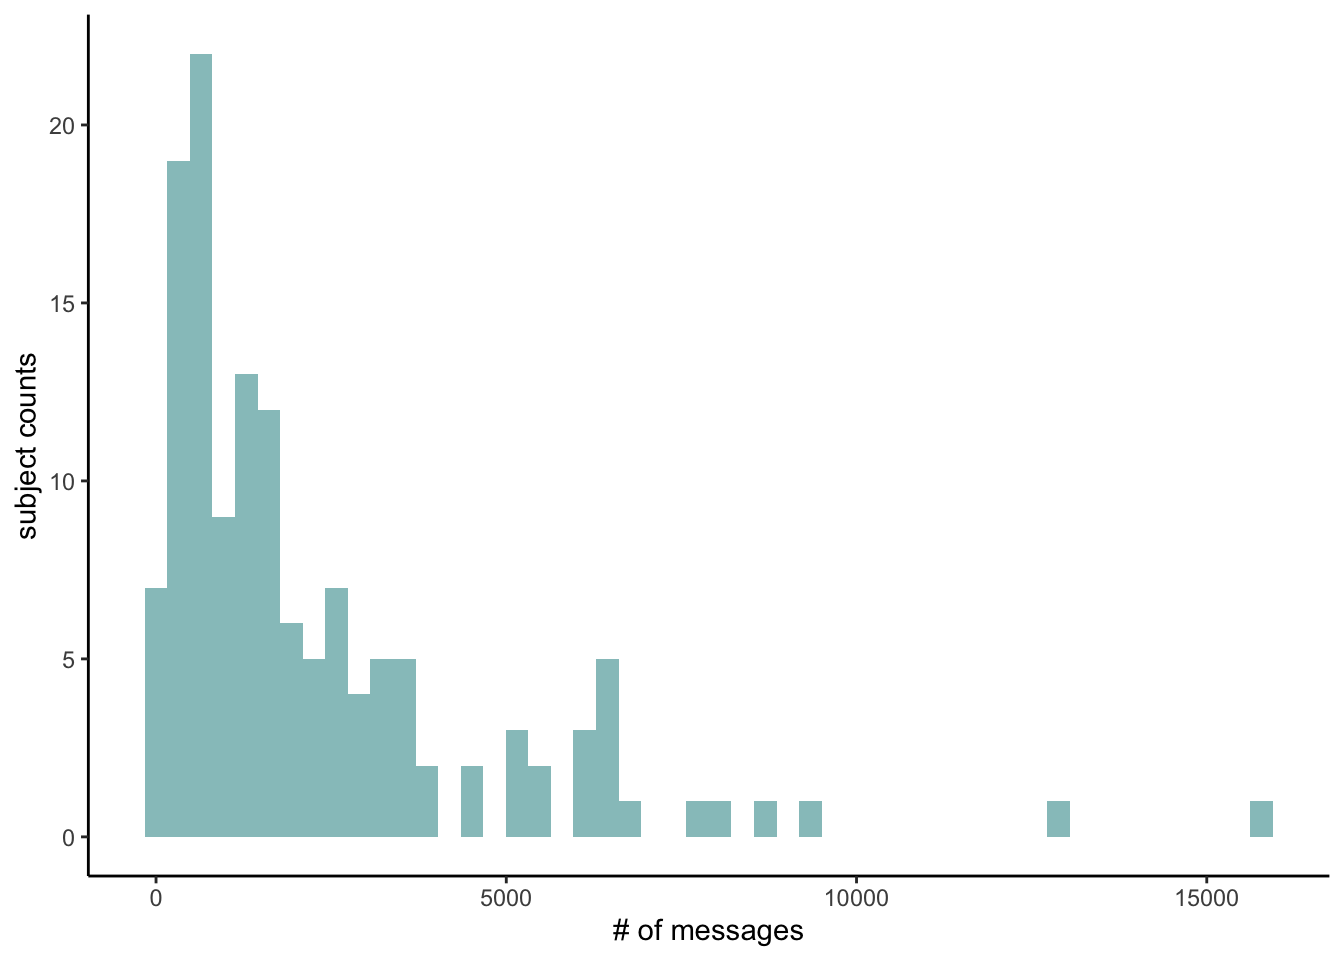

In [ ]:
raw_data |> 
    group_by(subid) |> 
    summarize(n = n()) |> 
    ggplot(aes(x = n)) + 
    geom_histogram(bins = 50, fill = "#97C4C5") +
    labs(x = "# of messages", y = "subject counts")


### Message Length per participant

> **Summary Table**

> Conclusion 1: The average message length is 10.4 (sd = 14.3, median = 7, range = 1 - 1266).

> Conclusion 2: On average, each participant has a mean message length of 10.87 (sd = 3.97, range = 5.25 - 38.91) and a median message length of 7.14 (sd = 2.3, range = 4 - 19).

In [ ]:
# mean/median message length across all messages
raw_data |> 
  mutate(text_length = lengths(strsplit(raw_data$body, "\\s+")))  |> 
  summarize(
    mean_length = mean(text_length),
    sd_length = sd(text_length),
    median_length = median(text_length),
    min_length = min(text_length),
    max_length = max(text_length)
  ) |> 
  print_kbl()


**Histogram on mean/median message length per participant**

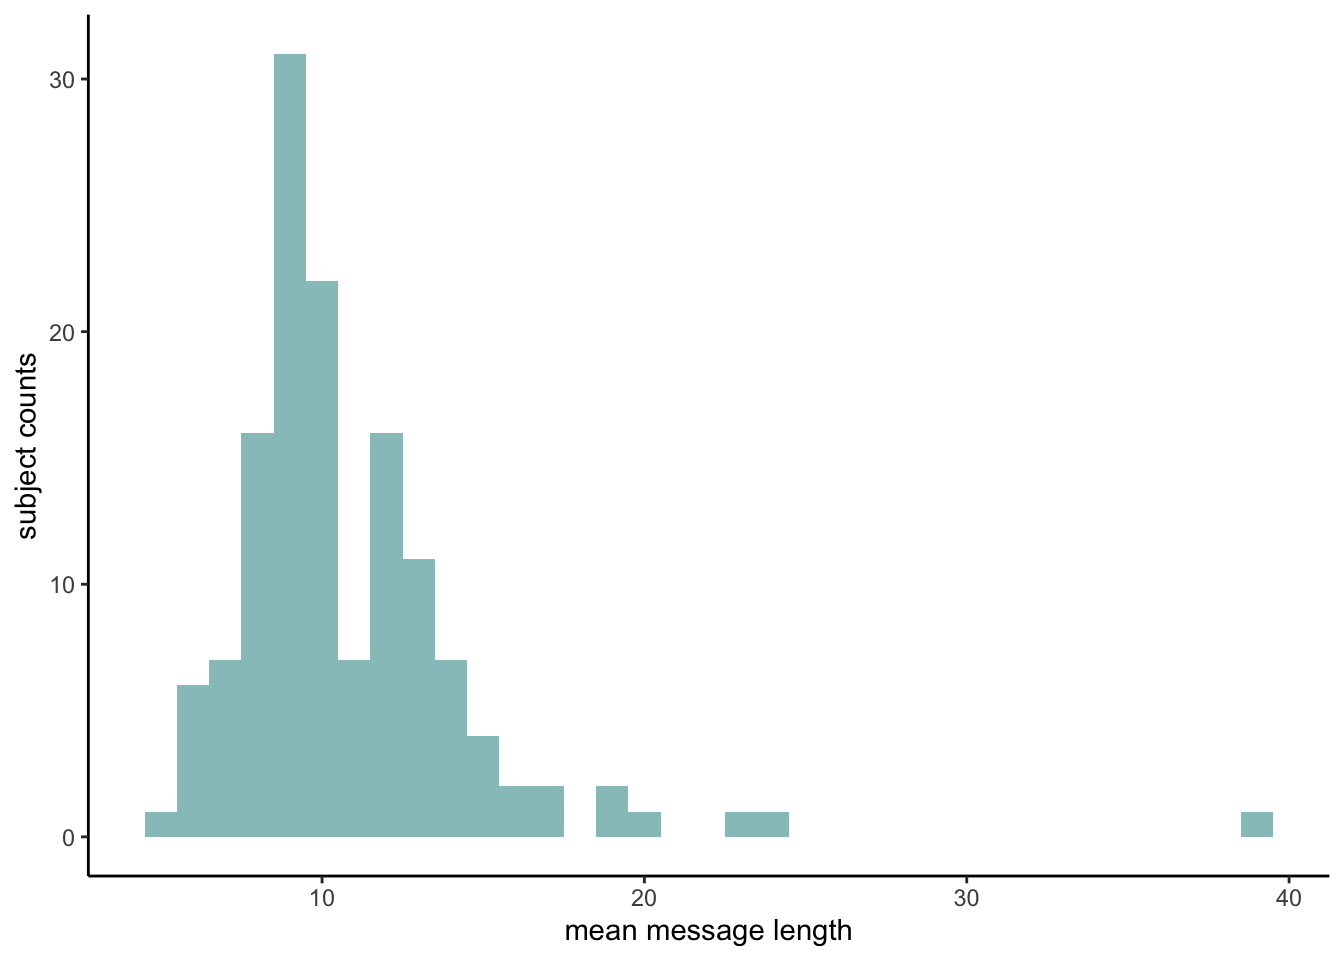

In [ ]:
raw_data |> 
  mutate(text_length = lengths(strsplit(raw_data$body, "\\s+")))  |> 
  group_by(subid) |> 
  summarize(mean_length = mean(text_length)) |> 
  ggplot(aes(x = mean_length)) + 
  geom_histogram(binwidth = 1, fill = "#97C4C5") +
  labs(x = "mean message length", y = "subject counts")


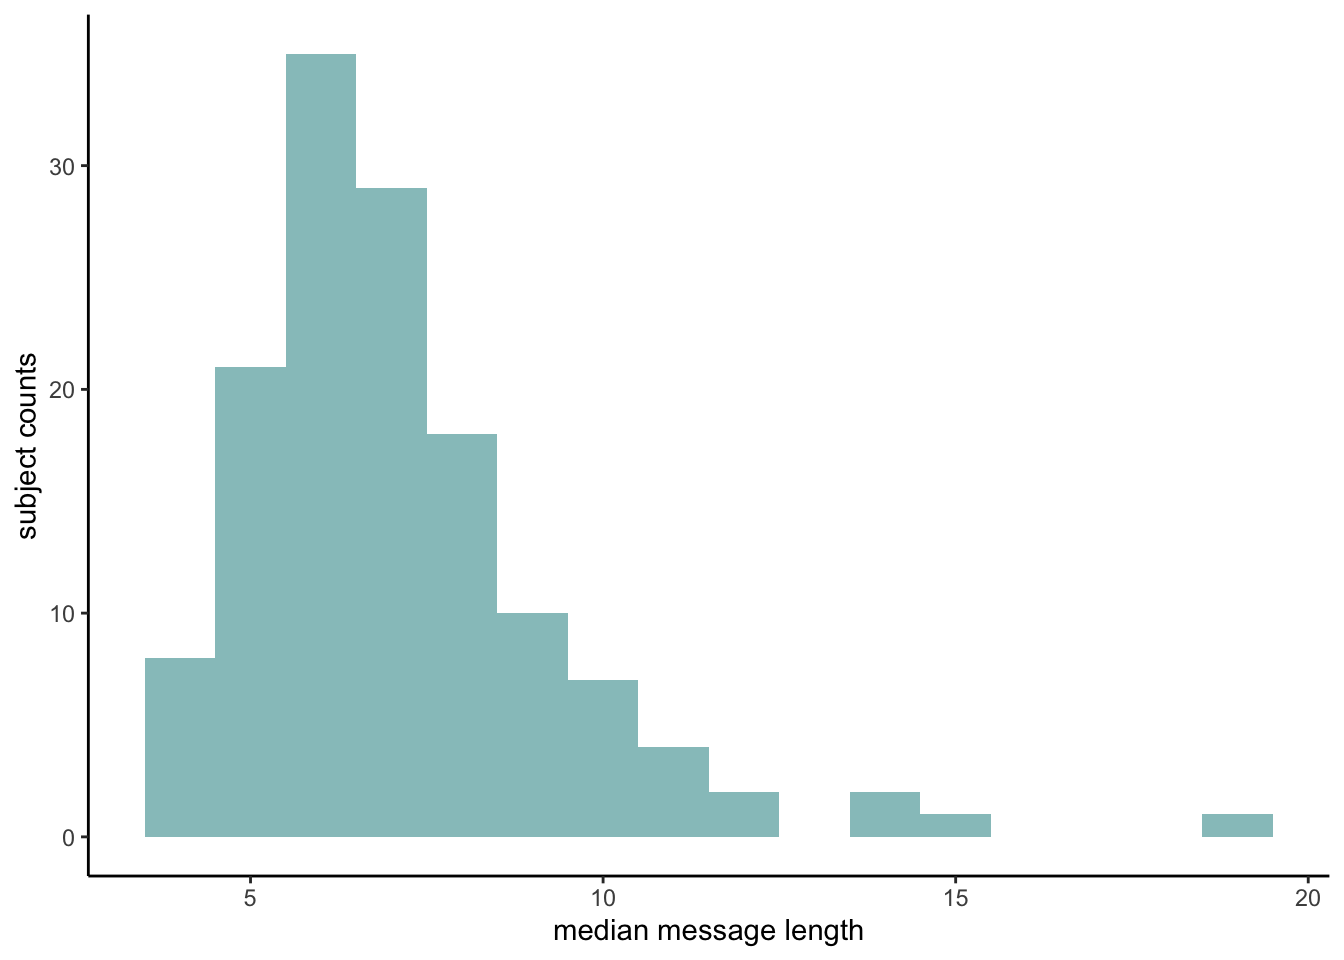

In [ ]:
raw_data |> 
  mutate(text_length = lengths(strsplit(raw_data$body, "\\s+")))  |> 
  group_by(subid) |> 
  summarize(median_length = median(text_length)) |> 
  ggplot(aes(x = median_length)) + 
  geom_histogram(binwidth = 1, fill = "#97C4C5") +
  labs(x = "median message length", y = "subject counts")


## EDA on prediction windows

prep: add in lapses that don’t have any predictors

In [ ]:
pred_3day <- pred_3day |> 
    full_join(
        labels,
        by = c("subid", "day_start", "day_end", "lapse")
    )

pred_1week <- pred_1week |> 
    full_join(
        labels,
        by = c("subid", "day_start", "day_end", "lapse")
    )

cat_3day <- cat_3day |> 
    full_join(
        labels,
        by = c("subid", "day_start", "lapse")
    )

cat_1week <- cat_1week |> 
    full_join(
        labels,
        by = c("subid", "day_start", "lapse")
    )


sanity check: if percentage of missingness is the same for individual messages and concatenated messages

In [ ]:
sum(
    pred_3day |> 
        group_by(subid, day_start) |> 
        summarize(na = any(is.na(body))) |> 
        pull(na)
) == 
nrow(
    cat_3day |> 
        filter(is.na(body))
)


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

[1] TRUE

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

[1] TRUE

### prediction window: 3-day

> Conclusion 1: On average, each lapse label has 79.2 messages (sd = 112, median = 40, range = 1 - 1414) during the 3-day prediction window.

> (**Missingness**) Conclusion 2: 11.9% of labels have no associated messages in the previous 3 days.

In [ ]:
pred_3day |> 
  group_by(subid, day_start) |> 
  summarize(n = n()) |>
  ungroup() |>
  summarize(
    mean = mean(n),
    sd = sd(n),
    median = median(n),
    min = min(n),
    max = max(n)
  )


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

# A tibble: 1 × 5
   mean    sd median   min   max
  <dbl> <dbl>  <dbl> <int> <int>
1  79.2  112.     40     1  1414

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

# A tibble: 1 × 1
  misssing
     <dbl>
1    0.119

**Distribution by label**

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

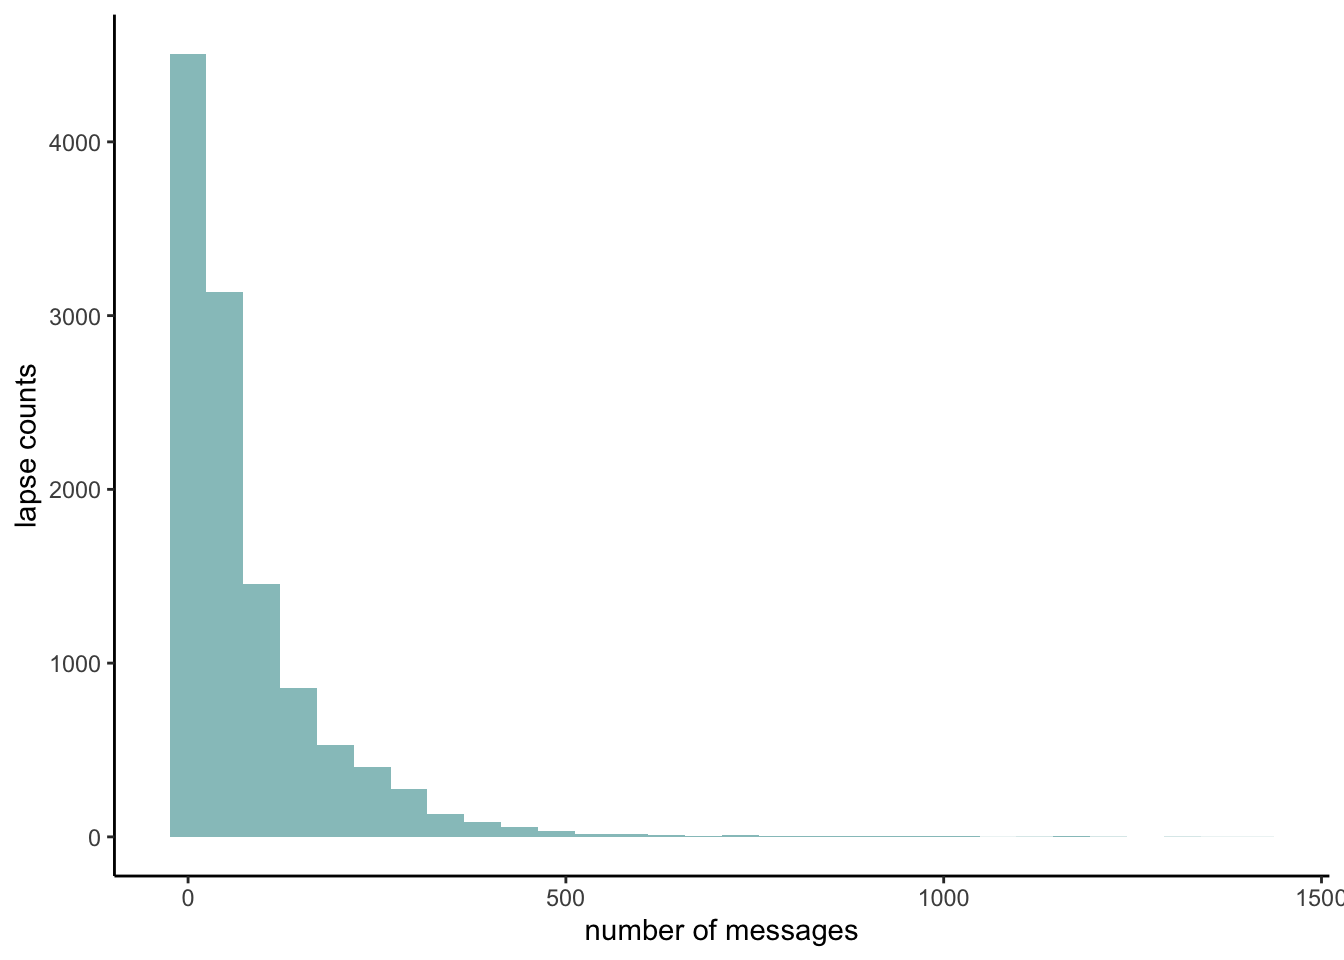

In [ ]:
pred_3day |> 
  group_by(subid, day_start) |> 
  summarize(n = n()) |> 
  ggplot(aes(x = n)) + 
  geom_histogram(fill = "#97C4C5") +
  labs(x = "number of messages", y = "lapse counts")


> Conclusion 1: Each participant has an averaged 79.48 messages as predictors per label (sd = 87.12, median = 50.12, range = 2.97 - 529.45).

> Conclusion 2: On average, each participant’s data missingness is 12% (sd = .19, median = 1%, range = 0% - 77%).

In [ ]:
pred_3day |> 
  group_by(subid, day_start) |> 
  summarize(
    n_messages = sum(!is.na(body)),
    missingness = sum(is.na(body)) / n()
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_messages = mean(n_messages),
    median_messages = median(n_messages),
    mean_missing = mean(missingness),
    median_missing = median(missingness)
  ) |> 
  summarize(
    mean_mean_messages = mean(mean_messages),
    sd_mean_messages = sd(mean_messages),
    median_mean_messages = median(mean_messages),
    min_mean_messages = min(mean_messages),
    max_mean_messages = max(mean_messages),
    mean_median_messages = mean(median_messages),
    sd_median_messages = sd(median_messages),
    median_median_messages = median(median_messages),
    min_median_messages = min(median_messages),
    max_median_messages = max(median_messages),
    mean_mean_missing = mean(mean_missing),
    sd_mean_missing = sd(mean_missing),
    median_mean_missing = median(mean_missing),
    min_mean_missing = min(mean_missing),
    max_mean_missing = max(mean_missing),
    mean_median_missing = mean(median_missing),
    sd_median_missing = sd(median_missing),
    median_median_missing = median(median_missing),
    min_median_missing = min(median_missing),
    max_median_missing = max(median_missing)
  ) |> 
  print_kbl()


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

**Distribution by participant**

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

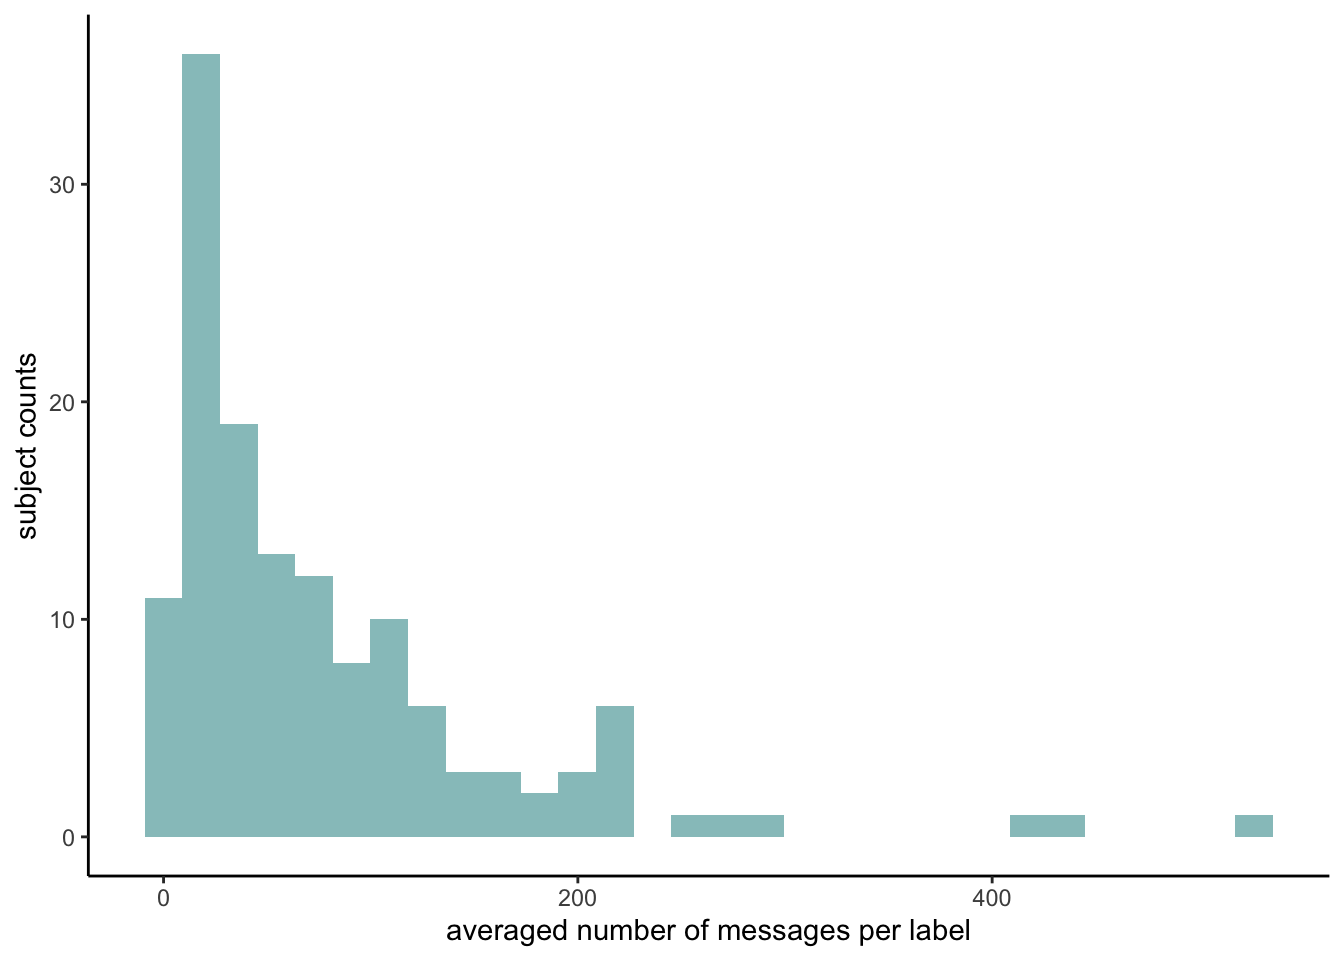

In [ ]:
pred_3day |> 
  group_by(subid, day_start) |> 
  summarize(
    n_messages = sum(!is.na(body))
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_messages = mean(n_messages)
  ) |>
  ggplot(aes(x = mean_messages)) +
  geom_histogram(fill = "#97C4C5") +
  labs(x = "averaged number of messages per label", y = "subject counts")


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

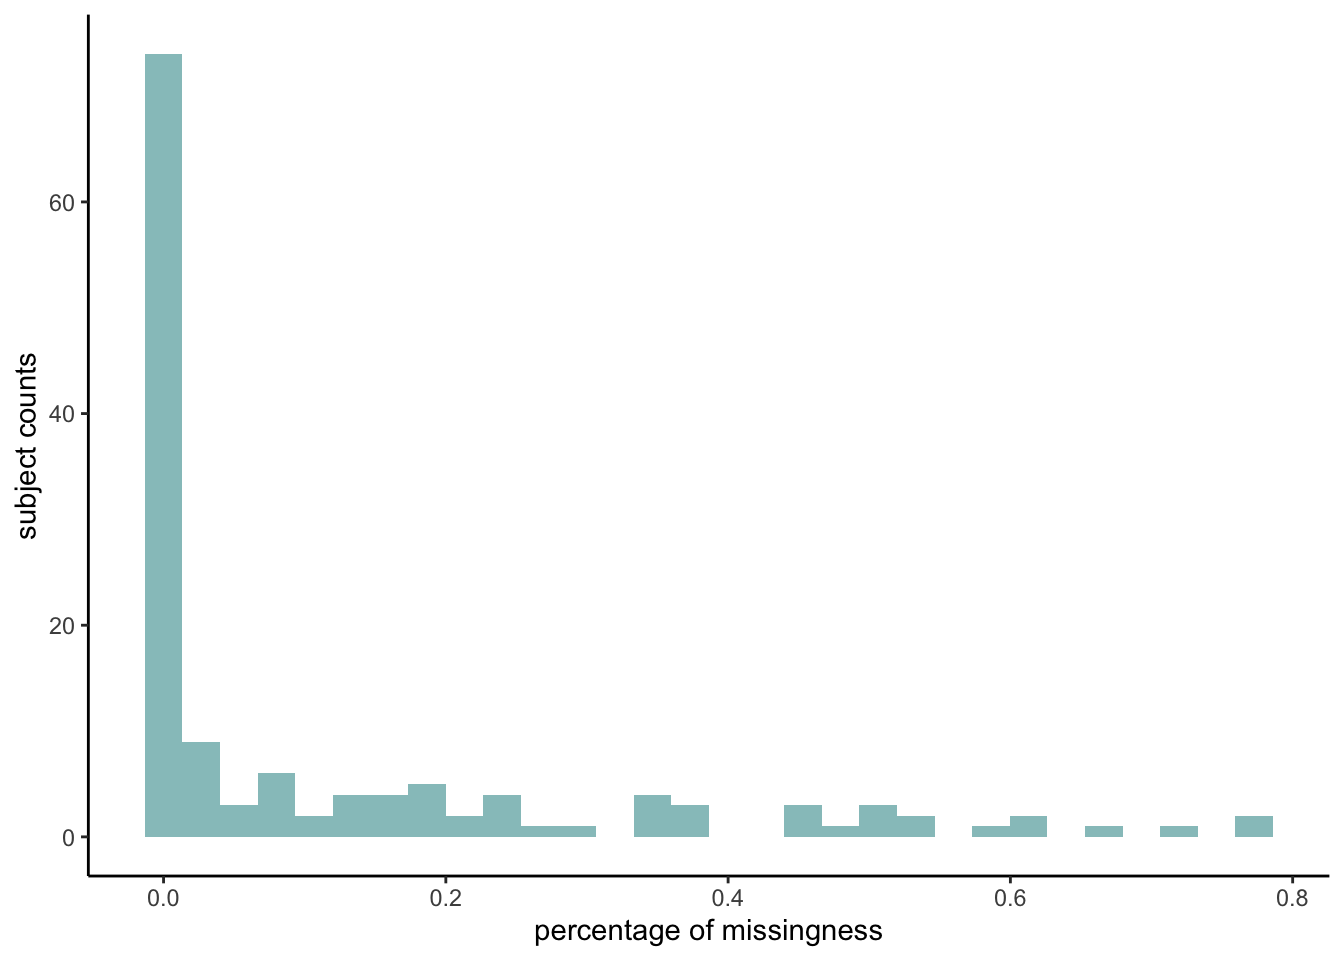

In [ ]:
pred_3day |> 
  group_by(subid, day_start) |> 
  summarize(
    missingness = sum(is.na(body)) / n()
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_missing = mean(missingness)
  ) |> 
  ggplot(aes(x = mean_missing)) +
  geom_histogram(fill = "#97C4C5") +
  labs(x = "percentage of missingness", y = "subject counts")


### prediction window: 1 week

> Conclusion 1: On average, each lapse label has 180 messages (sd = 241, median = 96, range = 1 - 2866) during the 1-week prediction window.

> (**Missingness**) Conclusion 2: 7.83% of labels have no associated messages in the previous week.

In [ ]:
pred_1week |> 
  group_by(subid, day_start) |> 
  summarize(n = n()) |>
  ungroup() |> 
  summarize(
    mean = mean(n),
    sd = sd(n),
    median = median(n),
    min = min(n),
    max = max(n)
  )


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

# A tibble: 1 × 5
   mean    sd median   min   max
  <dbl> <dbl>  <dbl> <int> <int>
1  180.  241.     96     1  2866

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

# A tibble: 1 × 1
  misssing
     <dbl>
1   0.0783

**Distribution by label**

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

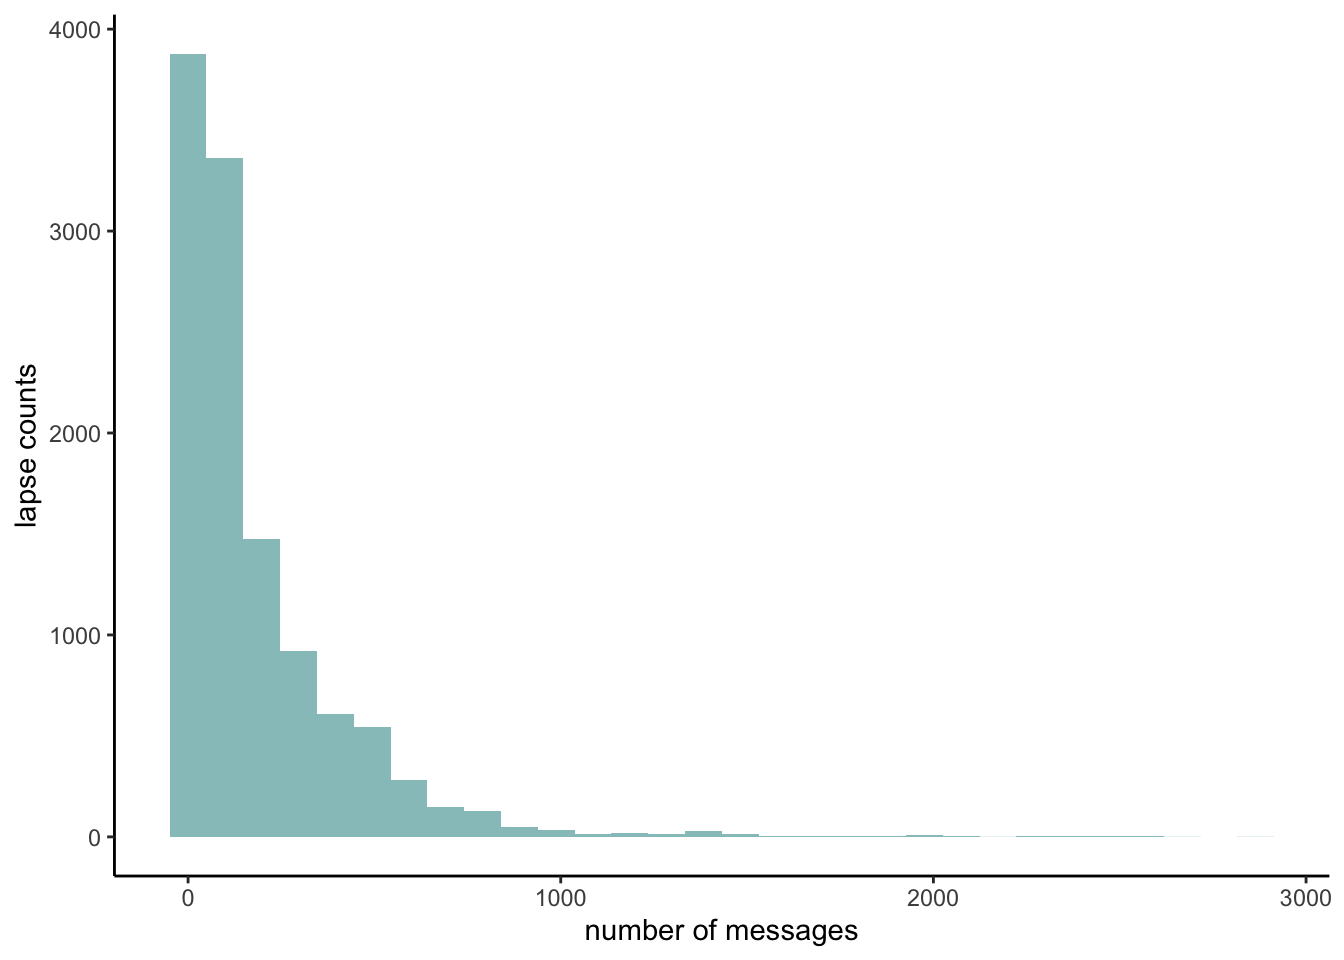

In [ ]:
pred_1week |> 
  group_by(subid, day_start) |> 
  summarize(n = n()) |> 
  ggplot(aes(x = n)) + 
  geom_histogram(fill = "#97C4C5") +
  labs(x = "number of messages", y = "lapse counts")


> Conclusion 1: Each participant has an averaged 181.23 messages as predictors per label (sd = 199.32, median = 113.47, range = 6.75 - 1200.76).

> Conclusion 2: On average, each participant’s data missingness is 8% (sd = .16, median = 0%, range = 0% - 73%).

In [ ]:
pred_1week |> 
  group_by(subid, day_start) |> 
  summarize(
    n_messages = sum(!is.na(body)),
    missingness = sum(is.na(body)) / n()
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_messages = mean(n_messages),
    median_messages = median(n_messages),
    mean_missing = mean(missingness),
    median_missing = median(missingness)
  ) |> 
  summarize(
    mean_mean_messages = mean(mean_messages),
    sd_mean_messages = sd(mean_messages),
    median_mean_messages = median(mean_messages),
    min_mean_messages = min(mean_messages),
    max_mean_messages = max(mean_messages),
    mean_median_messages = mean(median_messages),
    sd_median_messages = sd(median_messages),
    median_median_messages = median(median_messages),
    min_median_messages = min(median_messages),
    max_median_messages = max(median_messages),
    mean_mean_missing = mean(mean_missing),
    sd_mean_missing = sd(mean_missing),
    median_mean_missing = median(mean_missing),
    min_mean_missing = min(mean_missing),
    max_mean_missing = max(mean_missing),
    mean_median_missing = mean(median_missing),
    sd_median_missing = sd(median_missing),
    median_median_missing = median(median_missing),
    min_median_missing = min(median_missing),
    max_median_missing = max(median_missing)
  ) |> 
  print_kbl()


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

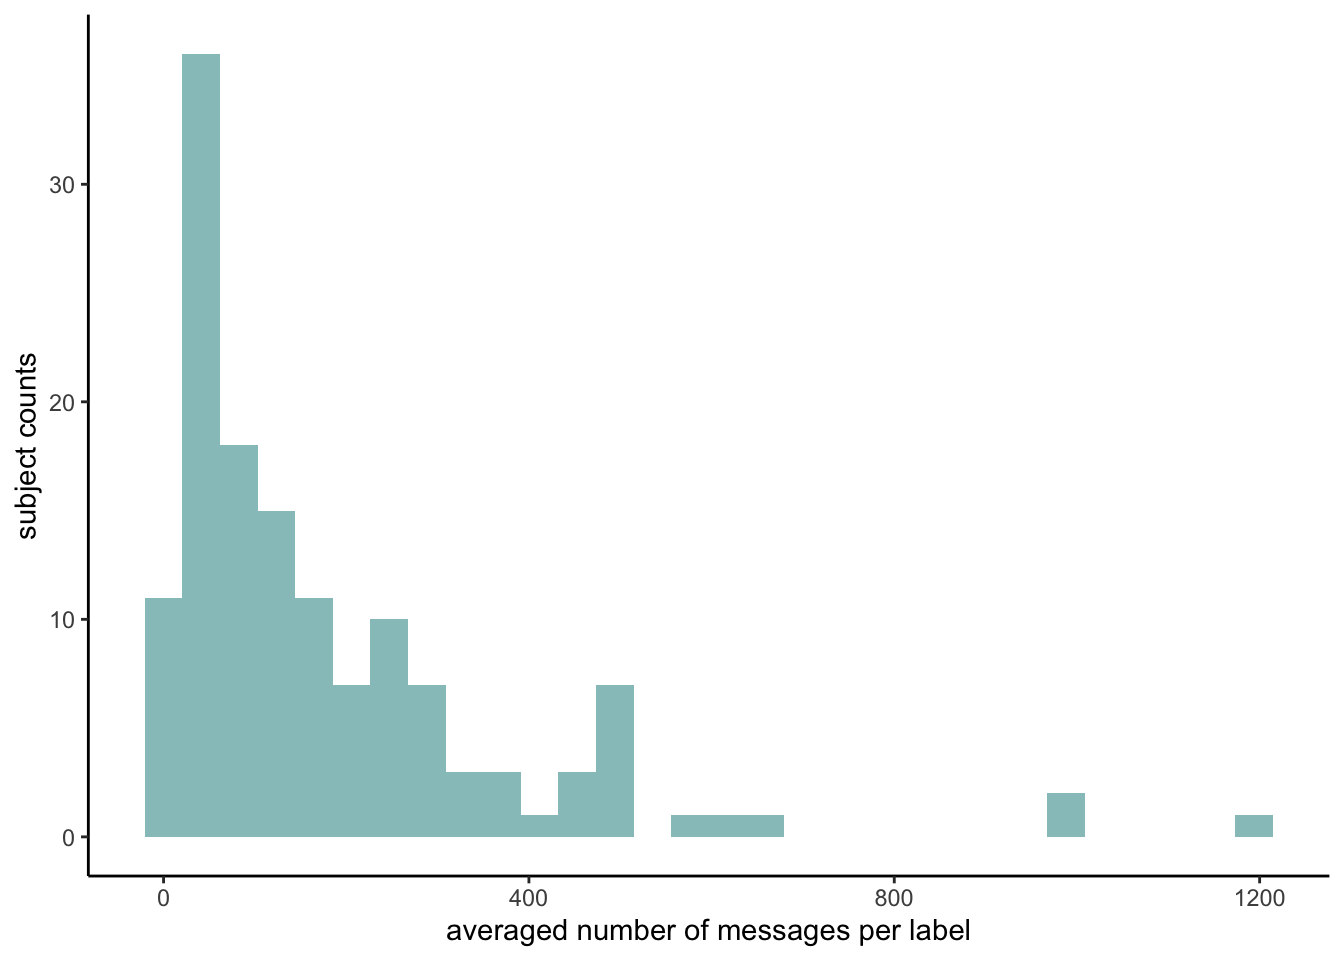

In [ ]:
pred_1week |> 
  group_by(subid, day_start) |> 
  summarize(
    n_messages = sum(!is.na(body))
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_messages = mean(n_messages)
  ) |>
  ggplot(aes(x = mean_messages)) +
  geom_histogram(fill = "#97C4C5") +
  labs(x = "averaged number of messages per label", y = "subject counts")


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

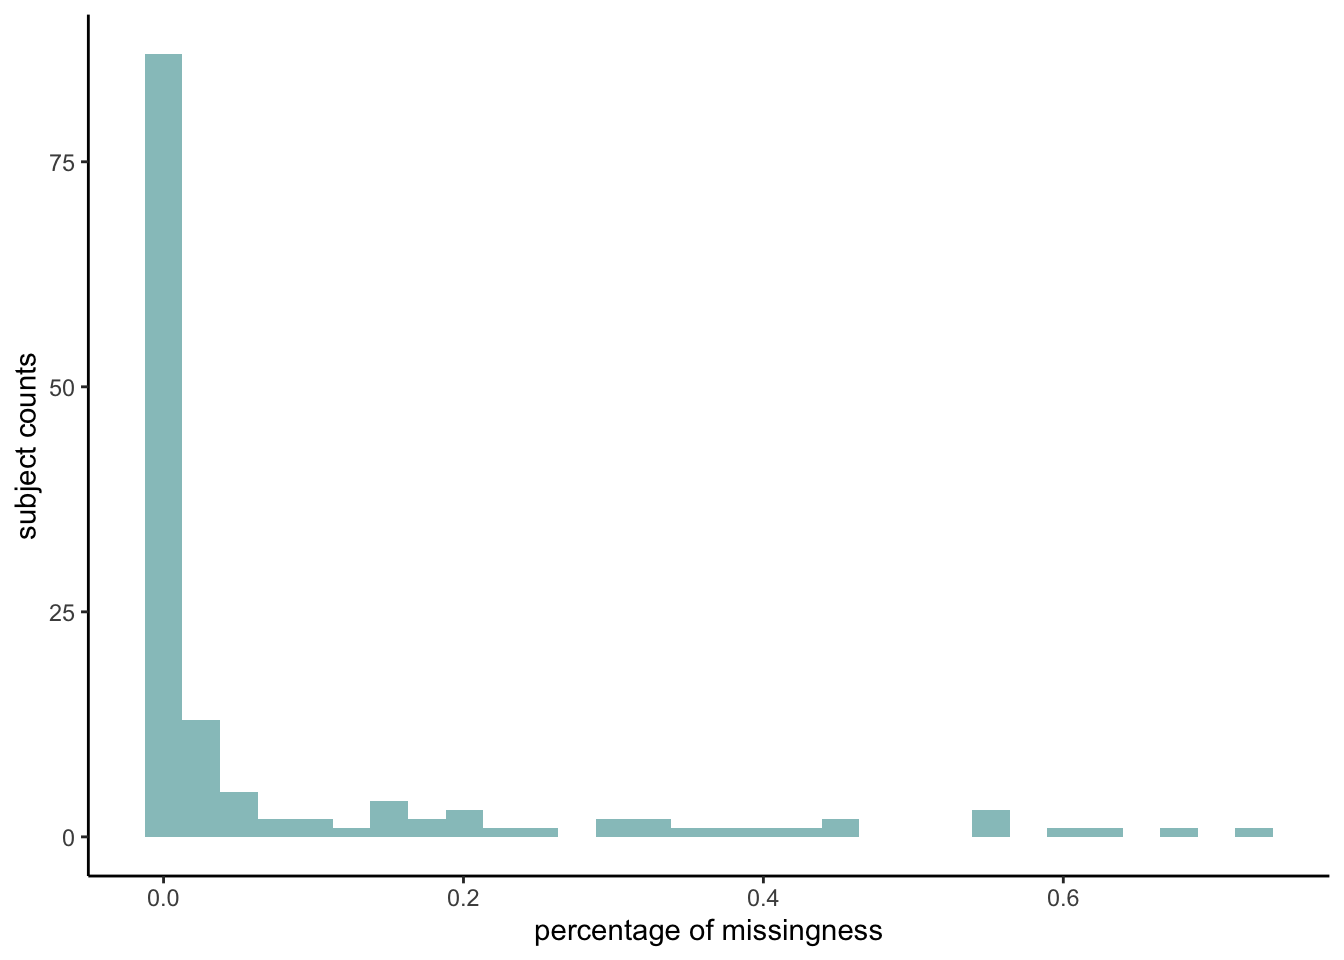

In [ ]:
pred_1week |> 
  group_by(subid, day_start) |> 
  summarize(
    missingness = sum(is.na(body)) / n()
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_missing = mean(missingness)
  ) |> 
  ggplot(aes(x = mean_missing)) +
  geom_histogram(fill = "#97C4C5") +
  labs(x = "percentage of missingness", y = "subject counts")
